# 3. Dimensionality Reduction

## 3.a. PCA on data

Since AGN lightcurves are stochastic and temporally correlated, we cannot apply PCA directly: there are no distinct 'features' in the time-series for the PCA to recreate with principle components... 

But I found this [blog post](https://medium.com/@heyamit10/principal-component-analysis-for-time-series-99a5d5eddac9) that discussed some basic approches. 

In the case of SMBHBs, we could do PCA in the frequency space without losing frequency-space features: 
- autocorrelation info (characteristic power-law $\tau$ shape of red noise in power spectrum/periodigram)
- periodicity info (peak in frequency space for sinusoidal signal).

This requires us to convert the data to frequency space to do the analysis, meaning it suffers from the same flaws as Lomb-Scargle periodigram analyses (e.g. bad at picking up non-sine periodicities).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from astropy.timeseries import LombScargle

jax.config.update("jax_enable_x64", True)

In [2]:
# GENERATE LIGHTCURVES
from eztaox.kernels.quasisep import Exp
from eztaox.simulator import UniVarSim
from eztaox.ts_utils import add_noise

n_lightcurves = 500 # nbr of lightcurves to be generated
frac_binaries = 0.7 # percentage that will contain sine periodicity

all_lightcurves = [] # time-series data
all_freq = []  # frequency of sine (0 if none)

min_dt, max_dt = 1.0, 3650.0 # days
logTau = np.random.uniform(np.log(20), np.log(30), size=n_lightcurves) # DRW timescale
logSigma = np.random.uniform(np.log(0.01), np.log(1.0), size=n_lightcurves) # signal variance 

for i in range(n_lightcurves):
    # setup single band DRW lightcurve model
    sim_params = {"log_kernel_param": jnp.asarray([logTau[i], logSigma[i]])}
    k = Exp(*sim_params["log_kernel_param"]) # DRW kernel 
    s = UniVarSim(k, min_dt, max_dt, sim_params) # simulator

    # simulate drw light curve, add noise
    sim_t, sim_y = s.random(500, jax.random.PRNGKey(i), jax.random.PRNGKey(i+100))
    sim_yerr = jnp.ones_like(sim_t) * 0.05
    sim_y = add_noise(sim_y, sim_yerr, jax.random.PRNGKey(i+200))

    sim_t = np.array(sim_t)
    sim_y = np.array(sim_y)
    sim_yerr = np.array(sim_yerr)

    # add sine for some lightcurves
    if i < int(frac_binaries * n_lightcurves):
        freq = np.random.uniform(1/500, 1/100)  # period [100,500] days
        amp = np.std(sim_y) ## arbitrarily chosen
        sine = amp * np.sin(2 * np.pi * freq * sim_t)
        sim_y = sim_y + sine
        all_freq.append(freq)
    else:
        all_freq.append(0.0)   
    all_lightcurves.append((sim_t, sim_y, sim_yerr))

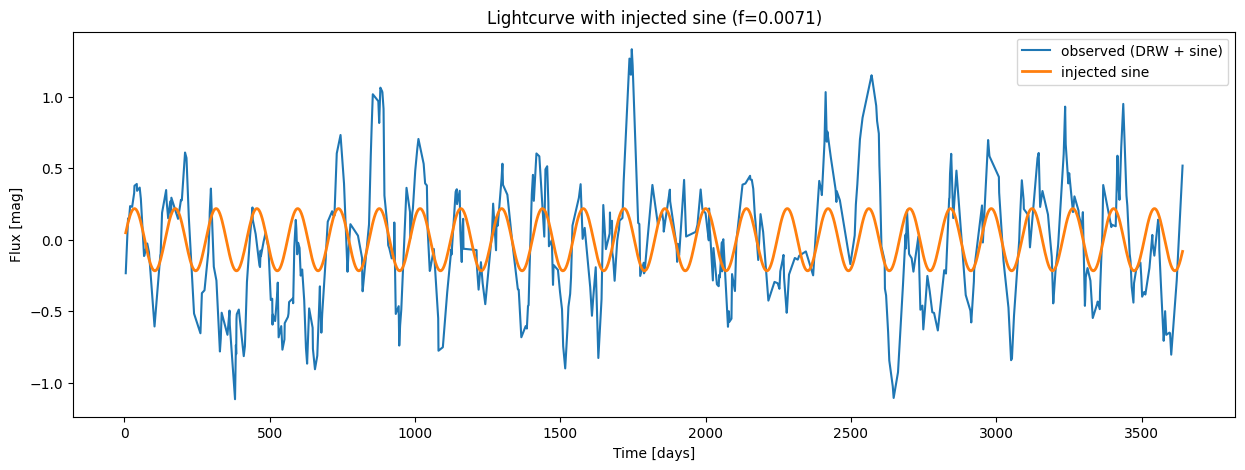

In [3]:
# visualize lightcurve
i = 0 
t, y, yerr = all_lightcurves[i]
freq = all_freq[i]

plt.figure(figsize=(15,5))
plt.plot(t, y, label="observed (DRW + sine)")
# sine only 
_t = np.linspace(np.min(t), np.max(t), 1000)
amp = np.std(y)*0.5
sine = amp * np.sin(2 * np.pi * freq * _t)
plt.plot(_t, sine, '-', linewidth=2, label="injected sine")

plt.xlabel("Time [days]"); plt.ylabel("Flux [mag]")
plt.title(f"Lightcurve with injected sine (f={freq:.4f})")
plt.legend()
plt.show()

In [4]:
# CONVERT TO FREQ-SPACE (LS PERIODIGRAM)
freq_grid = np.linspace(1/500, 1/100, 500)  # frequencies -- could let .autopower() figure it out, but this worked better
power_spectra = []
for t, y, yerr in all_lightcurves:
    ls = LombScargle(t, y, yerr)
    power = ls.power(freq_grid)
    power_spectra.append(power)

X = np.array(power_spectra)  # shape (n_lightcurvse, n_freq) 

In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

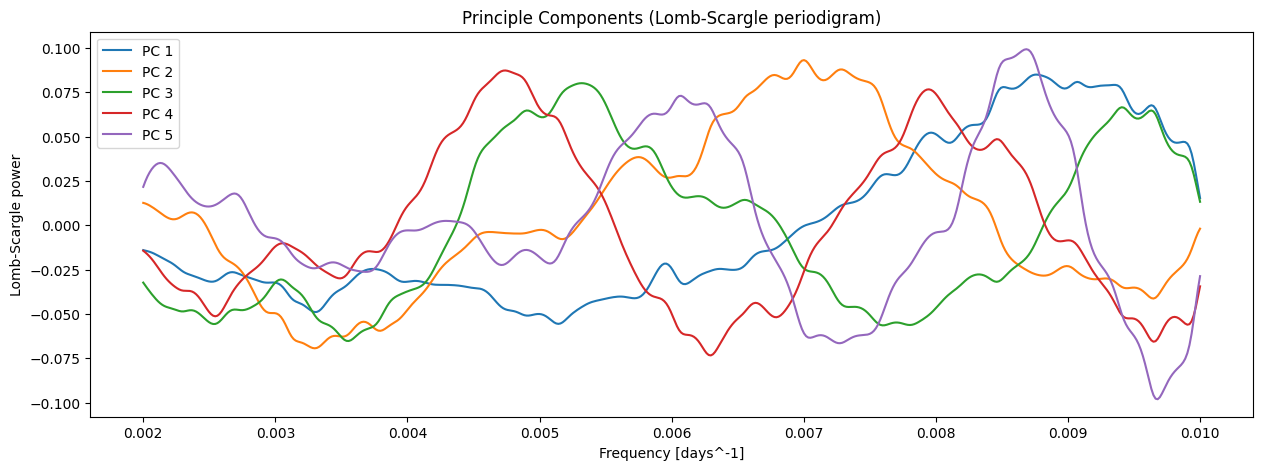

In [6]:
# check top PCs
plt.figure(figsize=(15,5))
for i in range(5):
    plt.plot(freq_grid, pca.components_[i], label=f"PC {i+1}")

plt.xlabel("Frequency [days^-1]"); plt.ylabel("Lomb-Scargle power")
plt.title("Principle Components (Lomb-Scargle periodigram)")
plt.legend()
plt.show()

We cannot assign physical meaning to each PC...

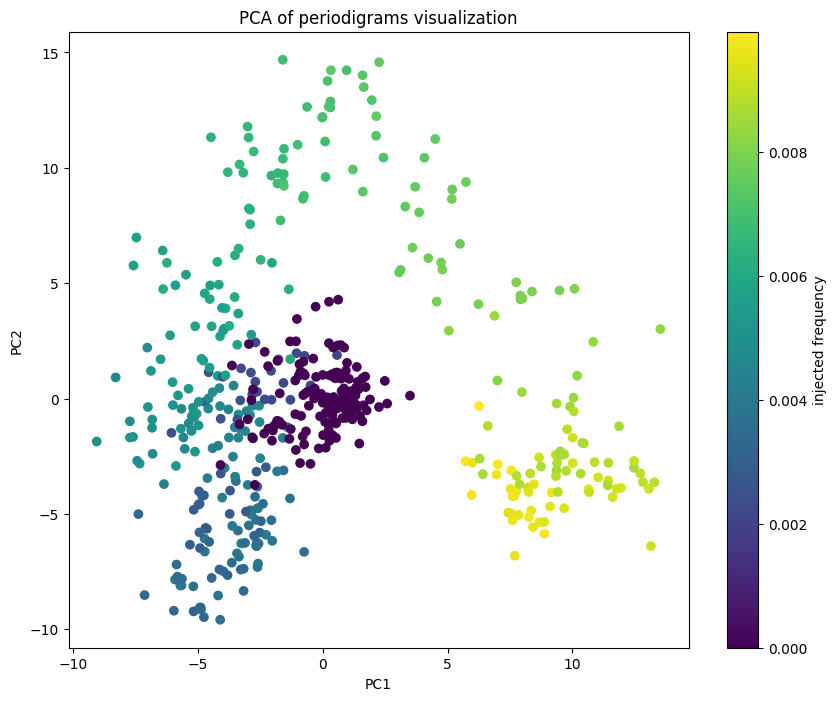

In [7]:
plt.figure(figsize=(10,8))
sc = plt.scatter(X_pca[:,0], X_pca[:,1], c=all_freq)
plt.colorbar(sc, label="injected frequency")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("PCA of periodigrams visualization")
plt.show()

There is clear clustering/trend on the physical property of sine frequency: the PCs are capturing physical meaning.

## 3.b. Scree Plot

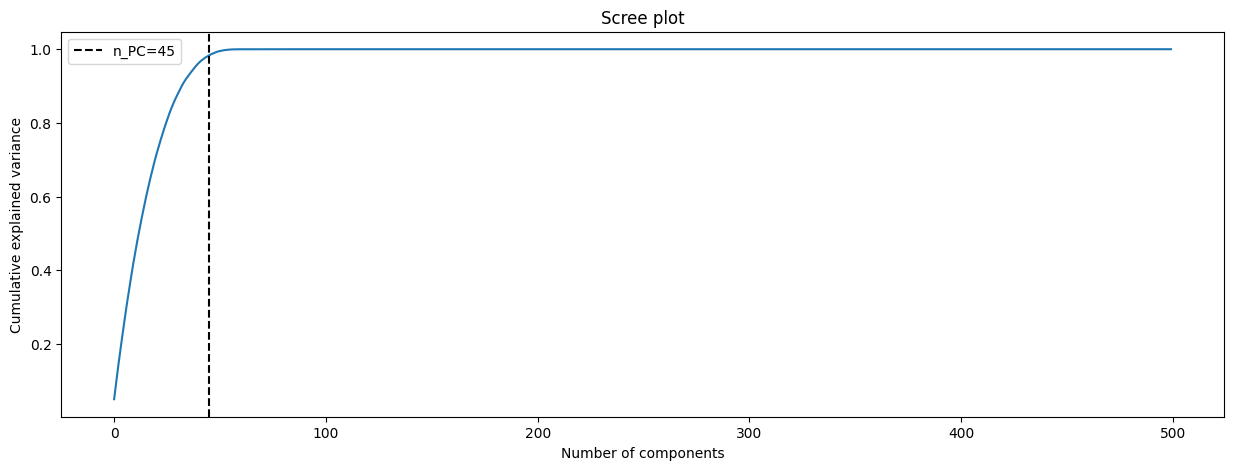

In [8]:
plt.figure(figsize=(15,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.axvline(x=45, c='k', linestyle='--', label='n_PC=45')

plt.xlabel("Number of components"); plt.ylabel("Cumulative explained variance")
plt.title("Scree plot")
plt.legend()
plt.show()

We can stop increasing nbr of PCs before the plateau: around 45 PCs seems good.

## 3.c. Reconstruction

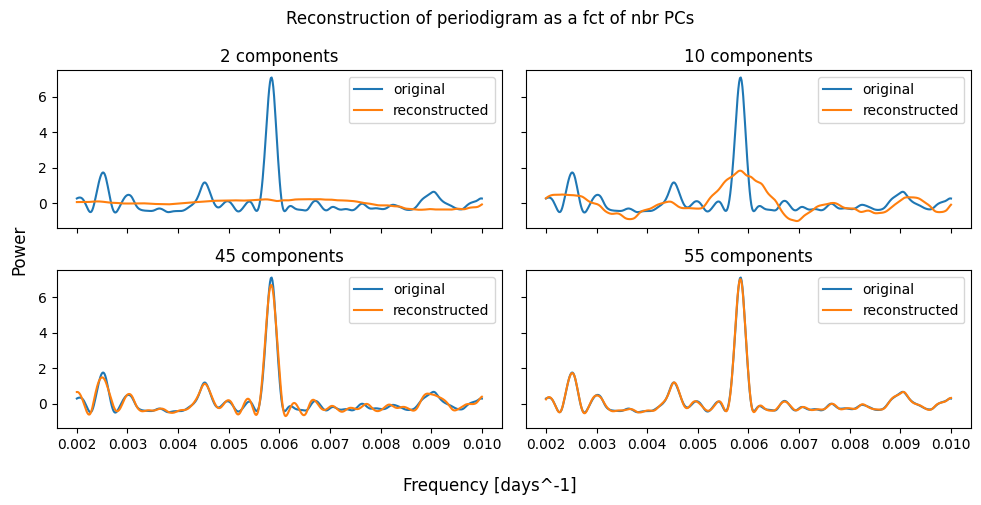

In [9]:
# choose a light curve
idx = 42
components_list = [2, 10, 45, 55]

# plot
fig, ax = plt.subplots(2, 2, figsize=(10, 5), sharex=True, sharey=True)
ax = ax.ravel()

for i, n in enumerate(components_list):
    # reconstruct using first n PCs
    X_recon = (X_pca[:, :n] @ pca.components_[:n, :]) + pca.mean_

    ax[i].plot(freq_grid, X_scaled[idx], label="original")
    ax[i].plot(freq_grid, X_recon[idx], label="reconstructed")

    ax[i].set_title(f"{n} components")
    ax[i].legend()

fig.supxlabel('Frequency [days^-1]'); fig.supylabel('Power')
fig.suptitle('Reconstruction of periodigram as a fct of nbr PCs')
plt.tight_layout()
plt.show()